[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MarcoBattiato/PH6725-AI-for-Science/blob/main/Classes/Class_1/01A-IntroductionToAIForScience.ipynb)

# 01A — Introduction to AI for Science

(by Marco Battiato. For questions/errors/bugs/typos report, please email at marco.battiato.teaching@gmail.com)

**PH6725 — Artificial Intelligence for Science**  
**Class 1, Notebook A — Hour 1**

**Instructor:** Marco Battiato (formerly Nanyang Assistant Professor @ Nanyang Technological University)

**email:**  marco.battiato.teaching@gmail.com

**In Person Classes:**  Wednesday 6:30pm - 9:45pm ()

**Consultation:** remote consultations are to be arranged by writing to marco.battiato.teaching@gmail.com

This notebook introduces the motivation for using machine learning in scientific research.  
It is not meant to teach all of machine learning. Its purpose is to give a coherent map of the field before we start studying individual methods.

## Learning Objectives

By the end of this notebook, students should be able to:

- distinguish Artificial Intelligence, Machine Learning, and Deep Learning;
- explain why machine learning is useful in modern scientific workflows;
- recognize that machine learning is a toolbox, not just neural networks;
- distinguish supervised learning, unsupervised learning, and representation learning;
- identify examples of machine learning in scientific research;
- explain the roles of data, representation, model, loss, training, and evaluation.

## How this notebook fits into the course

The course will later cover both **classical machine learning** and **deep learning** methods:

- regression and classification;
- decision trees, random forests, and gradient boosting;
- support vector machines and kernel methods;
- clustering and dimensionality reduction;
- neural networks, CNNs, transformers, and graph neural networks.

A central message of the course is:

> The best method depends on the data, the scientific question, and the assumptions we are willing to make.

# 1. Why Machine Learning?

## A traditional scientific workflow

A classical scientific workflow often starts with a phenomenon, followed by an explicit model constructed by the scientist.

Examples include:

- Newtonian mechanics;
- Maxwell's equations;
- quantum mechanics;
- population dynamics;
- reaction-rate equations.

In this workflow, the scientist specifies the structure of the model. Data are used mainly to test, calibrate, or refine the model.

In [21]:
# Plotting utilities used in this notebook

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch


def draw_box(ax, x, y, text, width=2.5, height=0.8, fontsize=12):
    box = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle="round,pad=0.08,rounding_size=0.08",
        linewidth=1.5,
        facecolor="white",
        edgecolor="black"
    )
    ax.add_patch(box)
    ax.text(
        x + width / 2,
        y + height / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize
    )
    return box


def draw_arrow(ax, start, end):
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="->",
        mutation_scale=16,
        linewidth=1.5,
        color="black"
    )
    ax.add_patch(arrow)
    return arrow


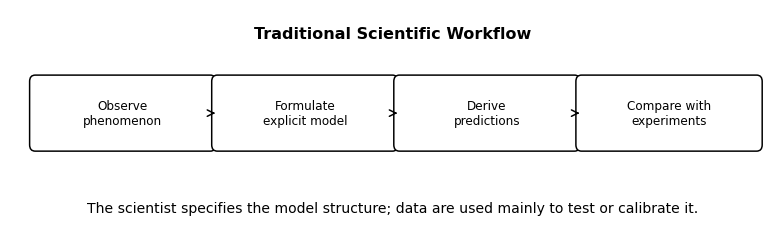

In [22]:
# Figure: traditional scientific workflow

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.set_xlim(0, 11)
ax.set_ylim(0, 3)
ax.axis("off")

ax.text(5.5, 2.65, "Traditional Scientific Workflow",
        ha="center", va="center", fontsize=16, fontweight="bold")

positions = [(0.4, 1.25), (3.0, 1.25), (5.6, 1.25), (8.2, 1.25)]
texts = [
    "Observe\nphenomenon",
    "Formulate\nexplicit model",
    "Derive\npredictions",
    "Compare with\nexperiments"
]

for pos, text in zip(positions, texts):
    draw_box(ax, *pos, text)

for i in range(len(positions) - 1):
    x0, y0 = positions[i]
    x1, y1 = positions[i + 1]
    draw_arrow(ax, (x0 + 2.5, y0 + 0.4), (x1, y1 + 0.4))

ax.text(5.5, 0.45,
        "The scientist specifies the model structure; data are used mainly to test or calibrate it.",
        ha="center", va="center", fontsize=14)

plt.tight_layout()
plt.show()

## A modern scientific situation

Modern science increasingly faces situations where:

- data are abundant;
- systems are highly complex;
- simulations are expensive;
- labels are difficult to obtain;
- first-principles models may be incomplete or computationally prohibitive.

Examples include:

- protein folding;
- astronomical surveys;
- particle detector reconstruction;
- materials discovery;
- climate modelling;
- high-dimensional biological data.

In these situations, we may attempt to learn patterns directly from data.

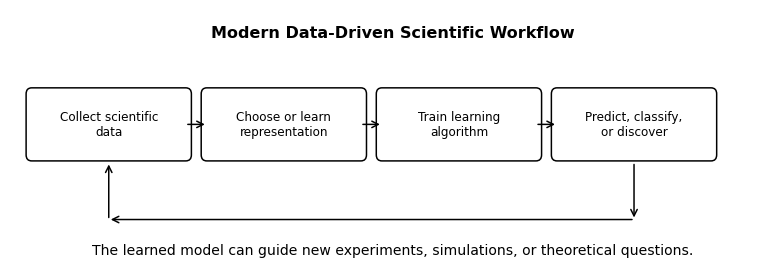

In [3]:
# Figure: modern data-driven workflow

fig, ax = plt.subplots(figsize=(11, 4.0))
ax.set_xlim(0, 11)
ax.set_ylim(0, 3.5)
ax.axis("off")

ax.text(5.5, 3.15, "Modern Data-Driven Scientific Workflow",
        ha="center", va="center", fontsize=16, fontweight="bold")

positions = [(0.35, 1.55), (2.85, 1.55), (5.35, 1.55), (7.85, 1.55)]
texts = [
    "Collect scientific\ndata",
    "Choose or learn\nrepresentation",
    "Train learning\nalgorithm",
    "Predict, classify,\nor discover"
]

for pos, text in zip(positions, texts):
    draw_box(ax, *pos, text, width=2.2)

for i in range(len(positions) - 1):
    x0, y0 = positions[i]
    x1, y1 = positions[i + 1]
    draw_arrow(ax, (x0 + 2.2, y0 + 0.4), (x1, y1 + 0.4))

# Feedback loop
arrow1 = FancyArrowPatch((8.95, 1.45), (8.95, 0.7), arrowstyle="->", mutation_scale=16, linewidth=1.5)
arrow2 = FancyArrowPatch((8.95, 0.7), (1.45, 0.7), arrowstyle="->", mutation_scale=16, linewidth=1.5)
arrow3 = FancyArrowPatch((1.45, 0.7), (1.45, 1.45), arrowstyle="->", mutation_scale=16, linewidth=1.5)
for arrow in [arrow1, arrow2, arrow3]:
    ax.add_patch(arrow)

ax.text(5.5, 0.3,
        "The learned model can guide new experiments, simulations, or theoretical questions.",
        ha="center", va="center", fontsize=14)

plt.tight_layout()
plt.show()

## Explicit modelling vs data-driven modelling

A simplified contrast is:

| Approach | What is specified by the scientist? | What is inferred from data? |
|---|---|---|
| Traditional modelling | The model structure | Parameters, tests, refinements |
| Machine learning | The learning procedure and model class | Patterns, relationships, representations |

This contrast is simplified. In practice, modern scientific work often combines both approaches.

For example, domain knowledge may determine:

- which variables to measure;
- what symmetries to enforce;
- which loss function to use;
- how to evaluate whether a prediction is scientifically meaningful.

## Discussion

Think of your own scientific field or research area.

Can you identify:

1. A problem where we have a good theoretical model, but simulation is expensive?
2. A problem where we have a lot of data, but incomplete theoretical understanding?
3. A problem where the main bottleneck is not prediction, but interpretation?

# 2. Artificial Intelligence, Machine Learning, and Deep Learning

In popular discussions, the terms **artificial intelligence**, **machine learning**, and **deep learning** are often used almost interchangeably.

For this course, it is important to distinguish them.

Machine learning is not a single algorithmic approach. It contains multiple model families with different assumptions, strengths, computational requirements, and typical use cases.

Different scientific problems involve different data regimes: small or large datasets, noisy or clean measurements, structured or tabular inputs, and varying needs for interpretability. Different model families are useful in different regimes.

## 2.1 Artificial Intelligence

**Artificial Intelligence (AI)** is the broad field concerned with building systems that exhibit behaviour we associate with intelligence.

Examples include:

- reasoning;
- search;
- planning;
- robotics;
- expert systems;
- machine learning.

Machine learning is one branch of AI, but AI is broader than machine learning.

## 2.2 Machine Learning

**Machine Learning (ML)** focuses on algorithms that improve their performance through experience.

Instead of explicitly programming every rule, we provide data and allow the system to infer useful patterns.

A useful simplified contrast is:

### Traditional programming

$$
\text{Rules} + \text{Data} \rightarrow \text{Answers}
$$

### Machine learning

$$
\text{Data} + \text{Answers} \rightarrow \text{Rules}
$$

This is only a simplified description, but it captures an important shift: in machine learning, part of the model is inferred from examples.

## 2.3 Deep Learning

**Deep Learning (DL)** is a family of machine learning methods based on neural networks with many layers.

Deep learning is especially powerful when:

- the dataset is large;
- the input is high-dimensional;
- useful features are difficult to engineer manually;
- the structure of the data is compatible with the architecture.

Examples include:

- images $\rightarrow$ convolutional neural networks;
- sequences and text $\rightarrow$ recurrent networks and transformers;
- graphs $\rightarrow$ graph neural networks.

However, deep learning is not always the best choice. For small, noisy, tabular scientific datasets, classical methods such as gradient boosting may be stronger, easier to train, and easier to interpret.

## 2.4 A broader view of Machine Learning

The following diagram gives a more balanced picture of the relationship between AI, ML, and DL.

Notice that Deep Learning is one branch of Machine Learning, not a replacement for all other methods.

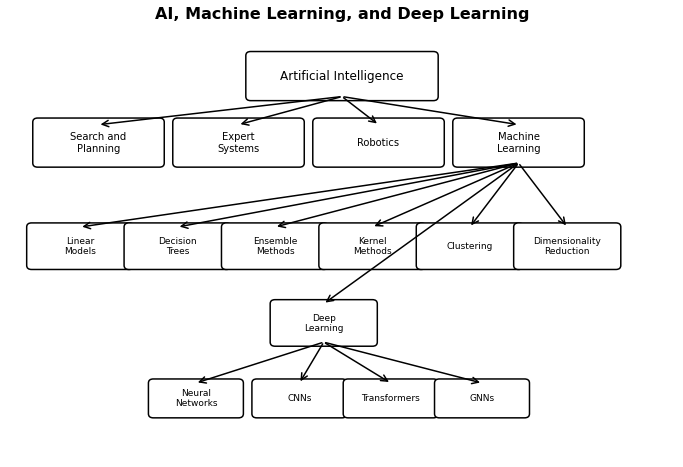

In [22]:
# Figure: AI, Machine Learning and Deep Learning taxonomy

fig, ax = plt.subplots(figsize=(12, 8))
ax.set_xlim(0, 11)
ax.set_ylim(0, 8.5)
ax.axis("off")

# Root
root_x = 4.0
root_y = 7.1
root_w = 3.0
root_h = 0.75

draw_box(ax, root_x, root_y,
         "Artificial Intelligence",
         width=root_w,
         fontsize=12)

# ------------------------------------------------------------------
# AI branches
# ------------------------------------------------------------------

branches = [
    ("Search and\nPlanning", 0.5, 5.8),
    ("Expert\nSystems",      2.8, 5.8),
    ("Robotics",             5.1, 5.8),
    ("Machine\nLearning",    7.4, 5.8),
]

branch_w = 2.0
branch_h = 0.75

for text, x, y in branches:

    draw_box(ax, x, y,
             text,
             width=branch_w,
             fontsize=10)

    # parent bottom center
    start = (
        root_x + root_w/2,
        root_y
    )

    # child top center
    end = (
        x + branch_w/2,
        y + branch_h
    )

    draw_arrow(ax, start, end)

# ------------------------------------------------------------------
# ML branches
# ------------------------------------------------------------------

ml_methods = [
    ("Linear\nModels",            0.4, 3.8),
    ("Decision\nTrees",           2.0, 3.8),
    ("Ensemble\nMethods",         3.6, 3.8),
    ("Kernel\nMethods",           5.2, 3.8),
    ("Clustering",                6.8, 3.8),
    ("Dimensionality\nReduction", 8.4, 3.8),
    ("Deep\nLearning",            4.4, 2.3),
]

ml_w = 1.6
ml_h = 0.75

for text, x, y in ml_methods:

    draw_box(ax,
             x,
             y,
             text,
             width=ml_w,
             height=ml_h,
             fontsize=9)

    # Machine Learning box
    parent_x = 7.4
    parent_y = 5.8

    start = (
        parent_x + branch_w/2,
        parent_y
    )

    end = (
        x + ml_w/2,
        y + ml_h
    )

    draw_arrow(ax, start, end)

# ------------------------------------------------------------------
# Deep Learning branches
# ------------------------------------------------------------------

dl_methods = [
    ("Neural\nNetworks", 2.4, 0.9),
    ("CNNs",             4.1, 0.9),
    ("Transformers",     5.6, 0.9),
    ("GNNs",             7.1, 0.9),
]

dl_w = 1.4
dl_h = 0.60

for text, x, y in dl_methods:

    draw_box(ax,
             x,
             y,
             text,
             width=dl_w,
             height=dl_h,
             fontsize=9)

    # Deep Learning parent
    parent_x = 4.4
    parent_y = 2.3

    start = (
        parent_x + ml_w/2,
        parent_y
    )

    end = (
        x + dl_w/2,
        y + dl_h
    )

    draw_arrow(ax, start, end)

ax.set_title(
    "AI, Machine Learning, and Deep Learning",
    fontsize=16,
    fontweight="bold"
)

plt.show()

## 2.5 Families of Machine Learning Models

Different machine learning methods make different assumptions. This is why there is no universally best algorithm.

In this course we will cover both classical machine learning and deep learning methods.

| Model family | Examples | Typical strengths | Typical limitations |
|---|---|---|---|
| Linear models | linear regression, logistic regression | simple, fast, interpretable | limited expressive power |
| Trees and ensembles | decision trees, random forests, gradient boosting | excellent for tabular data, robust, strong baselines | less natural for images, text, audio |
| Kernel methods | support vector machines, kernel ridge regression | effective on small datasets, geometric interpretation | poor scalability to very large datasets |
| Unsupervised methods | k-means, PCA, DBSCAN | useful when labels are unavailable | can be difficult to validate |
| Deep learning | CNNs, transformers, GNNs | learns representations from complex data | data-hungry, computationally expensive, less interpretable |

## 2.6 Inductive Bias

Every learning algorithm makes assumptions about the structure of the problem. These assumptions are called its **inductive bias**.

A model performs well when its inductive bias matches the structure of the data.

| Method | Typical inductive bias |
|---|---|
| Linear regression | Relationships are approximately linear |
| Decision trees | Good predictions can be obtained by hierarchical rules |
| Random forests | Many weak decision rules can be averaged into a robust model |
| Gradient boosting | Errors can be corrected sequentially by adding weak learners |
| Support vector machines | Classes can be separated by large-margin boundaries in a suitable feature space |
| k-means | Data form roughly compact clusters |
| PCA | Important variation lies along linear directions |
| CNNs | Nearby pixels are related; visual patterns can repeat in space |
| RNNs | Current state depends on previous states |
| Transformers | Relationships can exist between distant elements |
| GNNs | Object relations are encoded by graph connectivity |

This table is not meant as a precise mathematical classification. It is a way of emphasizing a practical lesson:

> Choosing a model means choosing assumptions about the structure of the data.

## 2.7 Dataset Size

Dataset size is one of the most important factors in machine learning.

The figure below is a qualitative sketch.  
It is not a benchmark result.

It illustrates a common pattern: different model families can behave differently as the amount of training data changes.

The precise behaviour depends on the dataset, the feature representation, the noise level, the model implementation, and the evaluation protocol.

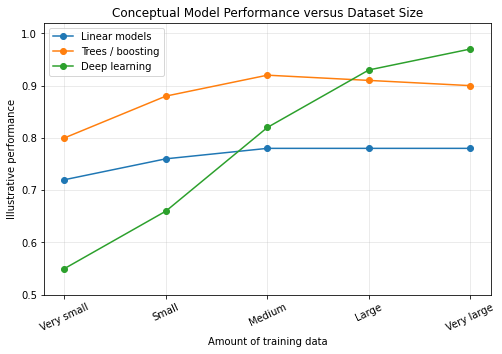

In [13]:
import numpy as np
import matplotlib.pyplot as plt

data_size = np.array([1, 2, 3, 4, 5])
labels = ["Very small", "Small", "Medium", "Large", "Very large"]

linear = np.array([0.72, 0.76, 0.78, 0.78, 0.78])
boosting = np.array([0.80, 0.88, 0.92, 0.91, 0.90])
deep = np.array([0.55, 0.66, 0.82, 0.93, 0.97])

plt.figure(figsize=(8, 5))
plt.plot(data_size, linear, marker="o", label="Linear models")
plt.plot(data_size, boosting, marker="o", label="Trees / boosting")
plt.plot(data_size, deep, marker="o", label="Deep learning")

plt.xticks(data_size, labels, rotation=25)
plt.ylim(0.5, 1.02)
plt.ylabel("Illustrative performance")
plt.xlabel("Amount of training data")
plt.title("Conceptual Model Performance versus Dataset Size")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Small datasets often favor models with stronger built-in structure, lower flexibility, or good use of handcrafted features.

Large datasets can support more flexible models, especially when the input has rich structure such as images, sequences, text, or graphs.

This does not establish a ranking of methods.  
It simply shows that the amount of available data affects which modelling assumptions are useful.

## 2.8 Noise Level

Scientific data are often noisy.

Noise may arise from:

- measurement uncertainty,
- detector limitations,
- sampling variability,
- uncontrolled external factors,
- imperfect labels,
- approximations in simulations.

The figure below illustrates that noise can interact with model flexibility.

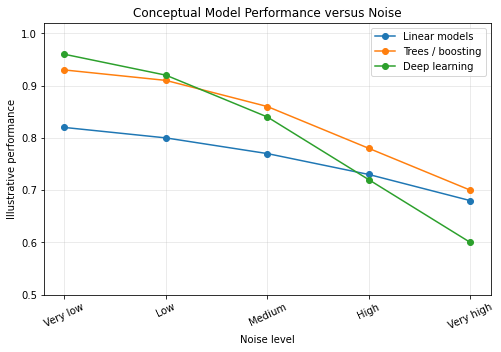

In [14]:
noise = np.array([1, 2, 3, 4, 5])
labels = ["Very low", "Low", "Medium", "High", "Very high"]

linear_noise = np.array([0.82, 0.80, 0.77, 0.73, 0.68])
boosting_noise = np.array([0.93, 0.91, 0.86, 0.78, 0.70])
deep_noise = np.array([0.96, 0.92, 0.84, 0.72, 0.60])

plt.figure(figsize=(8, 5))
plt.plot(noise, linear_noise, marker="o", label="Linear models")
plt.plot(noise, boosting_noise, marker="o", label="Trees / boosting")
plt.plot(noise, deep_noise, marker="o", label="Deep learning")

plt.xticks(noise, labels, rotation=25)
plt.ylim(0.5, 1.02)
plt.ylabel("Illustrative performance")
plt.xlabel("Noise level")
plt.title("Conceptual Model Performance versus Noise")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

This figure is also qualitative.

Increasing model flexibility is not automatically beneficial.  
A flexible model can represent complex structure, but it can also fit fluctuations that do not generalize.

This is one reason why validation, regularization, and careful experimental design are central in machine learning.

## 2.9 Interpretability, Flexibility, and Computational Cost

In scientific applications, predictive accuracy is often not the only objective.

We may also care about:

- understanding which variables matter,
- diagnosing model failures,
- checking whether a learned relation is physically plausible,
- estimating uncertainty,
- making predictions with limited computation.

Different model families offer different tradeoffs between interpretability, flexibility, and computational cost.

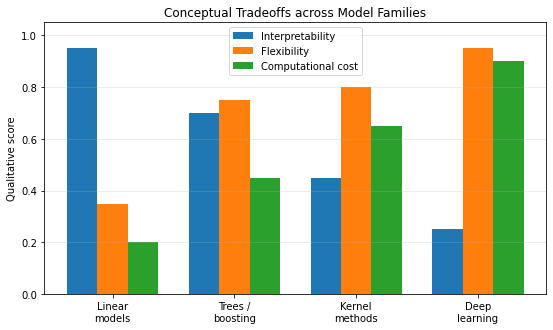

In [15]:
methods = ["Linear\nmodels", "Trees /\nboosting", "Kernel\nmethods", "Deep\nlearning"]

interpretability = [0.95, 0.70, 0.45, 0.25]
flexibility = [0.35, 0.75, 0.80, 0.95]
cost = [0.20, 0.45, 0.65, 0.90]

x = np.arange(len(methods))
width = 0.25

plt.figure(figsize=(9, 5))
plt.bar(x - width, interpretability, width, label="Interpretability")
plt.bar(x, flexibility, width, label="Flexibility")
plt.bar(x + width, cost, width, label="Computational cost")

plt.xticks(x, methods)
plt.ylim(0, 1.05)
plt.ylabel("Qualitative score")
plt.title("Conceptual Tradeoffs across Model Families")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.show()

This plot is a conceptual summary, not a measurement.

Some methods are easy to inspect but limited in the functions they can represent.  
Others are highly flexible but more computationally expensive and harder to interpret.

The appropriate balance depends on the scientific objective.

## 2.10 Comparing Different Families of Models


| Method Family | Typical Strengths | Typical Weaknesses |
|---|---|---|
| Linear Models | Simple, interpretable, fast | Limited expressiveness |
| Decision Trees | Easy to understand | Can overfit |
| Random Forests | Robust, strong tabular performance | Less interpretable |
| Gradient Boosting | Excellent on small/medium tabular data | Requires tuning |
| SVMs | Strong on small datasets | Poor scalability |
| PCA | Dimensionality reduction | Linear assumptions |
| Neural Networks | Flexible, general-purpose | Data-hungry |
| CNNs | Images and spatial data | Architecture-specific |
| Transformers | Sequences and language | Computationally expensive |
| GNNs | Graph-structured data | More complex training |


## 2.11 Machine Learning is a Toolbox

One of the central messages of this course is:

> New methods rarely eliminate older ones.

For example:

- PCA is still widely used.
- Linear regression is still widely used.
- Gradient boosting is still widely used.
- Neural networks are still widely used.

Machine learning accumulates tools rather than replacing them.

A machine learning practitioner should not think:

> Which neural network should I use?

but rather:

> Which assumptions best match my data and my scientific problem?

# 3. Historical Perspective

A common misconception is that machine learning evolved linearly from simple neural networks to modern deep learning.

In reality, the field has progressed through several waves, with different ideas becoming dominant at different times.

Many algorithms that remain important today were developed decades ago.

> Progress in machine learning often comes from the combination of new ideas, larger datasets, faster computers, and better software rather than from entirely new mathematics.

## 3.1 Timeline of Major Developments

| Period | Major developments |
|---|---|
| 1950s–1960s | Perceptrons, nearest-neighbour methods, early AI |
| 1970s–1980s | Statistical pattern recognition, clustering, linear models, PCA, decision trees |
| 1990s | Support Vector Machines, kernel methods, statistical learning theory |
| 2000s | Random forests, gradient boosting, large-scale statistical learning |
| 2010s | Deep learning, CNNs, large-scale representation learning |
| Late 2010s | Attention mechanisms, transformers |
| 2020s | Foundation models, diffusion models, graph neural networks |

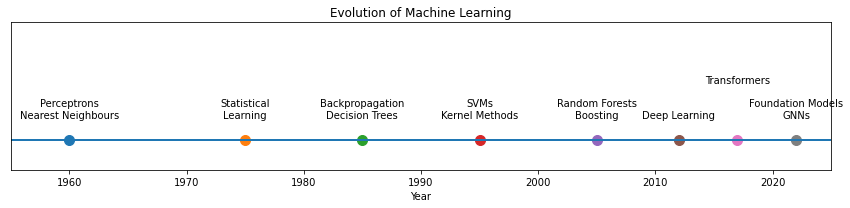

In [23]:

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,3))

years = [1960, 1975, 1985, 1995, 2005, 2012, 2017, 2022]
labels = [
    "Perceptrons\nNearest Neighbours",
    "Statistical\nLearning",
    "Backpropagation\nDecision Trees",
    "SVMs\nKernel Methods",
    "Random Forests\nBoosting",
    "Deep Learning",
    "Transformers\n\n\n",
    "Foundation Models\nGNNs"
]

ax.plot([1955, 2025], [0,0], linewidth=2)

for year, label in zip(years, labels):
    ax.scatter(year, 0, s=100)
    ax.text(year, 0.15, label, ha='center')

ax.set_xlim(1955, 2025)
ax.set_ylim(-0.2, 0.8)
ax.set_yticks([])
ax.set_xlabel("Year")
ax.set_title("Evolution of Machine Learning")

plt.tight_layout()
plt.show()

# 4. Types of Machine Learning

There are several ways to classify machine learning problems. The most common distinction is between supervised and unsupervised learning.

## 4.1 Supervised Learning

In supervised learning, we observe examples of the form:

$$
\text{input} \rightarrow \text{desired output}
$$

Examples:

- image $\rightarrow$ object category;
- molecular structure $\rightarrow$ energy;
- detector signal $\rightarrow$ particle type;
- experimental conditions $\rightarrow$ measured response.

The two most common supervised learning tasks are **regression** and **classification**.

### Regression

Regression means predicting a continuous value.

Examples:

- molecular energy;
- melting temperature;
- material band gap;
- physical parameter inferred from an experiment.

### Classification

Classification means predicting a discrete category.

Examples:

- signal vs background;
- diseased vs healthy;
- galaxy morphology class;
- stable vs unstable material.

## 4.2 Unsupervised Learning

In unsupervised learning, we observe only inputs. No labels are provided.

The goal is to discover structure in the data.

Examples:

- grouping galaxies by morphology;
- identifying phases of matter;
- clustering cell types;
- anomaly detection in detector data;
- reducing dimensionality for visualization.

Unsupervised learning is particularly important in science because labels are often expensive, ambiguous, or unavailable.

## 4.3 Representation Learning

A **representation** is a way of describing the data.

The same object can be represented in many ways. Some representations make a problem difficult; others make it simple.

Representation learning is the attempt to find useful representations automatically. It is not defined by whether labels are present: representations can be learned in supervised, unsupervised, or self-supervised ways.

This idea will appear repeatedly in the course:

- polynomial features;
- kernels;
- PCA;
- autoencoders;
- embeddings;
- neural networks;
- transformers;
- foundation models.

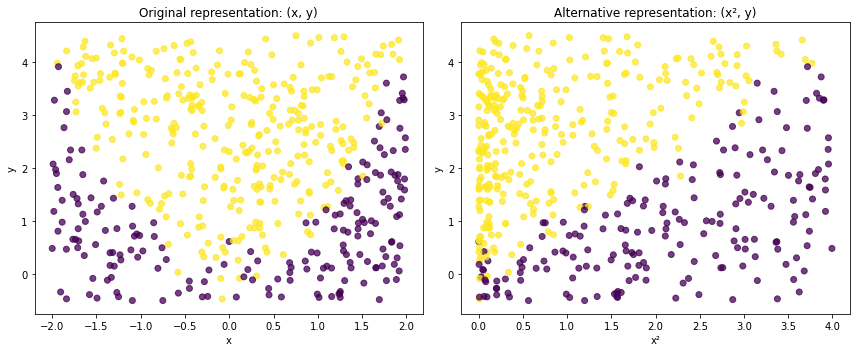

In [8]:
# A simple example: the same data can become easier to separate in a different representation.

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

x = rng.uniform(-2, 2, 500)
y = rng.uniform(-0.5, 4.5, 500)

# Two classes separated by an approximately parabolic boundary in the original coordinates.
label = (y > x**2 + 0.3 * rng.normal(size=500)).astype(int)

z = x**2

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(x, y, c=label, alpha=0.75)
ax[0].set_xlabel("x")
ax[0].set_ylabel("y")
ax[0].set_title("Original representation: (x, y)")

ax[1].scatter(z, y, c=label, alpha=0.75)
ax[1].set_xlabel("x²")
ax[1].set_ylabel("y")
ax[1].set_title("Alternative representation: (x², y)")

plt.tight_layout()
plt.show()

The data points are the same. Only the representation has changed.

In the original coordinates, the classes are separated by a curved boundary. In the transformed coordinates, they are approximately separated by a straight line.

This simple example illustrates a central idea in machine learning:

> Finding a good representation can be as important as choosing a learning algorithm.

# 5. Machine Learning in Scientific Research

Machine learning is used in science in many different ways. The following examples are not exhaustive, but they illustrate the diversity of scientific applications.

## 5.1 Particle Physics

Modern particle physics experiments produce enormous amounts of data.

Applications include:

- event classification;
- signal-background discrimination;
- particle identification;
- detector reconstruction;
- fast simulation and surrogate models.

A typical problem is to distinguish rare signal events from a much larger background.

## 5.2 Astronomy

Modern sky surveys observe huge numbers of celestial objects.

Applications include:

- galaxy classification;
- transient detection;
- photometric redshift estimation;
- anomaly detection;
- simulation-based inference.

## 5.3 Materials Science and Chemistry

Applications include:

- predicting material properties;
- discovering new compounds;
- molecular property prediction;
- reaction prediction;
- accelerating quantum chemistry or molecular dynamics calculations.

Many of these problems involve structured objects such as molecules and crystals. This is one reason graph neural networks are important in scientific AI.

## 5.4 Biology and Medicine

Applications include:

- protein structure and function prediction;
- genomics;
- single-cell analysis;
- microscopy;
- medical imaging;
- drug discovery.

Biological data are often high-dimensional, noisy, heterogeneous, and only partially labelled. This makes representation learning especially important.

# 6. The Machine Learning Workflow

At a high level, a machine learning project usually contains the following steps:

1. Collect or simulate data.
2. Choose a representation.
3. Choose a model.
4. Define a loss function or learning objective.
5. Train the model.
6. Evaluate performance.
7. Use the model for a scientific purpose.

The remainder of the course will largely be devoted to understanding these steps.

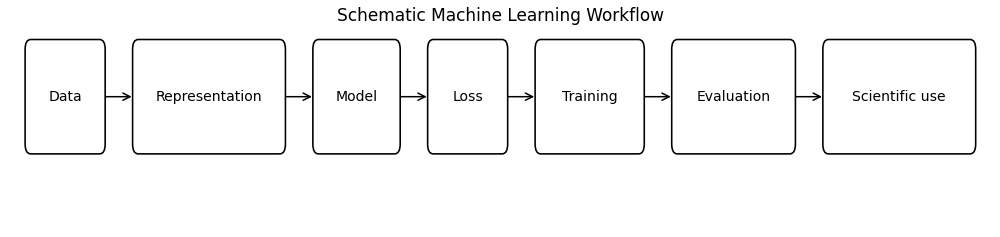

In [24]:
# Figure: schematic machine learning workflow

steps = [
    "Data",
    "Representation",
    "Model",
    "Loss",
    "Training",
    "Evaluation",
    "Scientific use"
]

box_height = 1.0
char_width = 0.13
min_width = 1.25
box_widths = [max(min_width, char_width * len(s) + 0.75) for s in steps]

gap = 0.65
x_lefts = []
current_x = 0.0

for w in box_widths:
    x_lefts.append(current_x)
    current_x += w + gap

total_width = current_x - gap

fig, ax = plt.subplots(figsize=(14, 3.4))
ax.set_xlim(-0.4, total_width + 0.4)
ax.set_ylim(-0.2, 1.8)
ax.axis("off")

y0 = 0.65

for x0, w, label in zip(x_lefts, box_widths, steps):
    box = FancyBboxPatch(
        (x0, y0),
        w,
        box_height,
        boxstyle="round,pad=0.08,rounding_size=0.10",
        linewidth=1.6,
        facecolor="white",
        edgecolor="black"
    )
    ax.add_patch(box)
    ax.text(x0 + w / 2, y0 + box_height / 2, label,
            ha="center", va="center", fontsize=14)

for i in range(len(steps) - 1):
    start = (x_lefts[i] + box_widths[i] + 0.06, y0 + box_height / 2)
    end = (x_lefts[i + 1] - 0.06, y0 + box_height / 2)
    arrow = FancyArrowPatch(
        start, end,
        arrowstyle="->",
        mutation_scale=18,
        linewidth=1.5,
        color="black"
    )
    ax.add_patch(arrow)

ax.set_title("Schematic Machine Learning Workflow", fontsize=17, pad=12)

plt.tight_layout()
plt.show()

## 6.1 Data

Data may come from:

- experiments;
- simulations;
- surveys;
- sensors;
- images;
- text;
- biological sequences;
- molecular or graph structures.

The quality, quantity, and bias of the data strongly affect what can be learned.

## 6.2 Representation

A representation determines what the model actually sees.

Examples:

- a material represented by composition features;
- a molecule represented by a graph;
- an image represented by pixels;
- a protein represented as an amino-acid sequence;
- a time series represented by recent history.

Poor representations can make simple problems hard. Good representations can make hard problems easier.

## 6.3 Model, Loss, Training, Evaluation

A **model** maps inputs to predictions.

A **loss function** measures how wrong the predictions are.

Training means adjusting model parameters to reduce the loss.

Evaluation asks whether the model works on data it has not seen before.

This distinction is crucial: a model can perform very well on training data and still fail scientifically if it does not generalize.

# 7. Four Scientific Uses of Machine Learning

Machine learning is not used only for prediction. In scientific research, it often plays several different roles.

## 7.1 Prediction

Estimate unknown quantities.

Examples:

- molecular energies;
- material properties;
- weather variables;
- physical parameters.

## 7.2 Classification

Assign categories.

Examples:

- disease diagnosis;
- particle identification;
- galaxy morphology;
- stable vs unstable material.

## 7.3 Discovery

Identify previously unknown patterns.

Examples:

- clustering;
- anomaly detection;
- dimensionality reduction;
- identifying phases or regimes.

## 7.4 Surrogate Models

Replace expensive computations with fast approximations.

Examples:

- molecular dynamics;
- climate simulations;
- finite-element simulations;
- quantum chemistry;
- detector simulation.

Surrogate models can be very useful, but they must be treated carefully: they may fail outside the region where they were trained.

# 8. A First Tiny Machine Learning Example

We now show a minimal example of the machine-learning workflow.

Do not worry if some details are not yet clear.  
The goal is simply to see the structure of a typical ML problem:

1. generate or collect data;
2. choose a model;
3. train the model;
4. evaluate the result;
5. use the model for prediction.

We will revisit each step carefully later in the course.

## 8.1 Problem

Suppose we observe noisy measurements of a simple physical relation.

There is an input variable $x$ and an observed output $y$.

We would like to learn a function

$$
\hat{y} = f(x)
$$

that predicts $y$ from $x$.

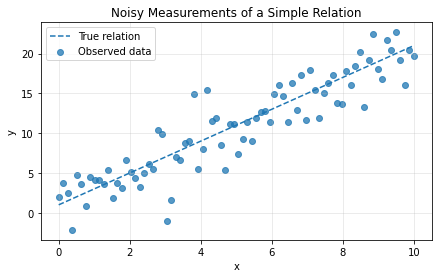

In [16]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(1)

# Synthetic data
n = 80
x = np.linspace(0, 10, n)
true_y = 2.0 * x + 1.0
observed_y = true_y + rng.normal(scale=3.0, size=n)

plt.figure(figsize=(7, 4))
plt.scatter(x, observed_y, alpha=0.75, label="Observed data")
plt.plot(x, true_y, linestyle="--", label="True relation")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Noisy Measurements of a Simple Relation")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 8.2 Fit a Simple Model

Here we fit a straight line:

$$
\hat{y} = ax + b
$$

This is one of the simplest possible machine-learning models.

The model has two parameters:

- slope $a$;
- intercept $b$.

Training means finding values of $a$ and $b$ that make the predictions close to the observed data.

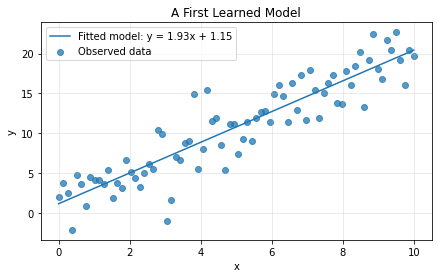

Estimated slope:     1.928
Estimated intercept: 1.146


In [17]:
# Fit a straight line using NumPy
a, b = np.polyfit(x, observed_y, deg=1)

predicted_y = a * x + b

plt.figure(figsize=(7, 4))
plt.scatter(x, observed_y, alpha=0.75, label="Observed data")
plt.plot(x, predicted_y, label=f"Fitted model: y = {a:.2f}x + {b:.2f}")
plt.xlabel("x")
plt.ylabel("y")
plt.title("A First Learned Model")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Estimated slope:     {a:.3f}")
print(f"Estimated intercept: {b:.3f}")

## 8.3 Evaluate the Model

A common way to evaluate a regression model is to measure the average squared error:

$$
\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

This is not the only possible metric, but it is a useful first example.

In [ ]:
mse = np.mean((observed_y - predicted_y)**2)
print(f"Mean squared error: {mse:.3f}")

## 8.4 What This Example Shows

This tiny example contains the basic ingredients of machine learning:

| Step | In this example |
|---|---|
| Data | Noisy observations of $x$ and $y$ |
| Representation | The input variable $x$ |
| Model | A straight line $\hat{y} = ax+b$ |
| Loss / objective | Squared error |
| Training | Choosing $a$ and $b$ |
| Evaluation | Mean squared error |
| Scientific use | Predicting $y$ for new values of $x$ |

Later in the course, the models will become more sophisticated, but the workflow will remain similar.

## 8.5 Why This Preview Matters

Even this simple example already raises important questions:

- What if the true relation is not linear?
- What if the data are noisy?
- What if we have too few measurements?
- How do we know whether the model will work on new data?
- Should we prefer a simple interpretable model or a more flexible one?

These questions motivate much of the course.

# 9. Looking Ahead

During this course we will study:

- how to formulate learning problems;
- how to evaluate models;
- classical methods such as trees, boosting, SVMs, clustering, and PCA;
- neural networks and backpropagation;
- deep learning architectures such as CNNs and transformers;
- representation learning and graph neural networks;
- scientific applications throughout.

The guiding question will be:

> Which method is appropriate for this scientific problem, and why?

# 10. Exercises and Discussion Questions

## Exercise 1: Task Types

Classify each task as regression, classification, clustering, dimensionality reduction, or surrogate modelling.

1. Predicting the melting temperature of a material.
2. Determining whether a detector event contains a Higgs boson.
3. Grouping galaxies according to morphology without labels.
4. Replacing a slow numerical simulation with a fast neural network approximation.
5. Compressing high-dimensional gene-expression data into two dimensions for visualization.

## Exercise 2: Your Research Area

Identify one problem in your field that could potentially benefit from machine learning.

What would be:

- the inputs?
- the outputs?
- the available data?
- the main difficulty?

Possible difficulties include limited data, noisy data, expensive labels, high dimensionality, interpretability, or extrapolation outside the training set.

## Exercise 3: Model Choice

Suppose you have 300 experimental samples and 50 measured features.

Would you start with a deep neural network? Why or why not?

What other methods might you try first?

# 11. Key Takeaways

- Machine Learning learns patterns from data.
- Deep Learning is a powerful branch of Machine Learning, not a replacement for all other methods.
- Classical methods such as linear models, trees, boosting, SVMs, clustering, and PCA remain important.
- Every model has an inductive bias: it makes assumptions about the structure of the data.
- Representation matters: the same data can be easy or difficult depending on how it is represented.
- Scientific uses of machine learning include prediction, classification, discovery, and surrogate modelling.
- A good practitioner asks: **which assumptions best match my data and my scientific problem?**